In [1]:
pip install scikit-image scikit-learn matplotlib


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from skimage.filters import sobel
from skimage.feature import canny


# Données

**importation**

In [5]:
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X_img = data.images   # (400, 64, 64) floats in [0,1]
y = data.target       # 0..39

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_img, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train_img.shape, "Test:", X_test_img.shape)


Train: (300, 64, 64) Test: (100, 64, 64)


**Visualisaiton**

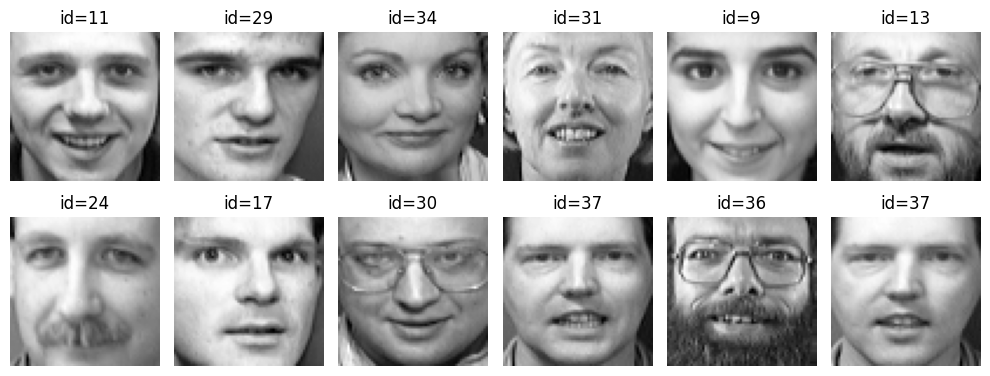

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, i in zip(axes.ravel(), range(12)):
    ax.imshow(X_img_train[i], cmap="gray")
    ax.set_title(f"id={y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


# 1. Extraction de caractéristiques


**1.1 Descripteur 1 — Histogramme (niveaux de gris)**

In [7]:
def feat_hist_gray(images, bins=32):
    feats = []
    for img in images:
        hist, _ = np.histogram(img, bins=bins, range=(0.0, 1.0), density=True)
        feats.append(hist)
    return np.array(feats)


In [8]:
Xtr_hist = feat_hist_gray(X_train_img, bins=32)
Xte_hist = feat_hist_gray(X_test_img, bins=32)
print("Hist features:", Xtr_hist.shape)


Hist features: (300, 32)


**Descripteur 2 — Contours (Sobel + seuillage) + stats simples**

Calcule le gradient Sobel (force des contours), puis on fait un seuillage pour obtenir une edge map binaire

In [9]:
def feat_edges_sobel(images, threshold=0.12):
    feats = []
    for img in images:
        G = sobel(img)                 # magnitude du gradient
        edges = (G > threshold)        # seuillage -> image binaire (contours / non-contours)

        # features simples (faciles à expliquer)
        edge_density = edges.mean()    # % de pixels qui sont des contours
        grad_mean = G.mean()           # moyenne du gradient
        grad_std = G.std()             # écart-type du gradient
        grad_edges_mean = G[edges].mean() if edges.sum() > 0 else 0.0

        feats.append([edge_density, grad_mean, grad_std, grad_edges_mean])
    return np.array(feats)



In [10]:
Xtr_edge = feat_edges_sobel(X_train_img, threshold=0.12)
Xte_edge = feat_edges_sobel(X_test_img, threshold=0.12)
print("Edge features (Sobel):", Xtr_edge.shape)


Edge features (Sobel): (300, 4)


**Canny**

In [11]:
def feat_edges_canny(images, sigma=1.5):
    feats = []
    for img in images:
        edges = canny(img, sigma=sigma)
        edge_density = edges.mean()
        feats.append([edge_density])
    return np.array(feats)

Xtr_canny = feat_edges_canny(X_train_img, sigma=1.5)
Xte_canny = feat_edges_canny(X_test_img, sigma=1.5)
print("Edge features (Canny):", Xtr_canny.shape)


Edge features (Canny): (300, 1)


**Fusion des features (Histogramme + Contours)**

In [12]:
Xtr_fusion = np.hstack([Xtr_hist, Xtr_edge])
Xte_fusion = np.hstack([Xte_hist, Xte_edge])
print("Fusion features:", Xtr_fusion.shape)


Fusion features: (300, 36)


# 3. Classification — Régression Logistique (même modèle pour tout)

In [13]:
def eval_logreg(Xtr, Xte, ytr, yte, C=10.0):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, C=C))
    ])
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)
    return accuracy_score(yte, ypred)


results = {}
results["Histogramme"] = eval_logreg(Xtr_hist, Xte_hist, y_train, y_test)
results["Contours (Sobel)"] = eval_logreg(Xtr_edge, Xte_edge, y_train, y_test)
results["Fusion (Hist+Sobel)"] = eval_logreg(Xtr_fusion, Xte_fusion, y_train, y_test)
results["Contours (Canny)"] = eval_logreg(Xtr_canny, Xte_canny, y_train, y_test)

for k, v in results.items():
    print(f"{k:18s} -> Accuracy = {v:.4f}")


Histogramme        -> Accuracy = 0.8100
Contours (Sobel)   -> Accuracy = 0.3700
Fusion (Hist+Sobel) -> Accuracy = 0.8400
Contours (Canny)   -> Accuracy = 0.0500


Visualisation

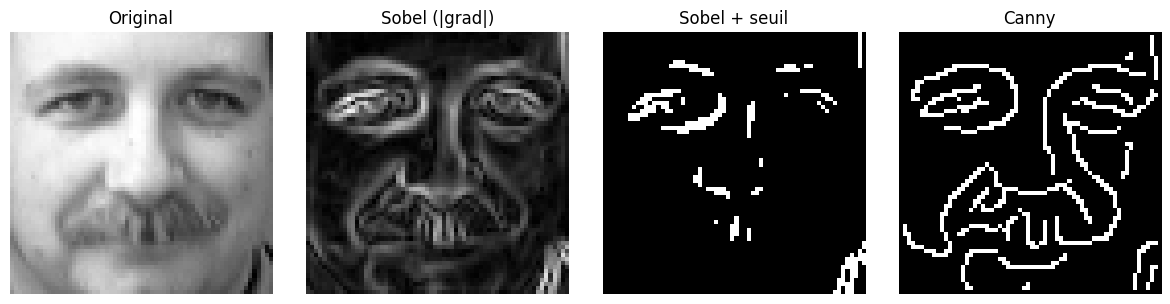

In [14]:
from skimage.filters import sobel
from skimage.feature import canny

img = X_test_img[0]
G = sobel(img)
edges_bin = (G > 0.12)
edges_c = canny(img, sigma=1.5)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(G, cmap="gray"); plt.title("Sobel (|grad|)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(edges_bin, cmap="gray"); plt.title("Sobel + seuil"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(edges_c, cmap="gray"); plt.title("Canny"); plt.axis("off")
plt.tight_layout(); plt.show()
